# F5 — Deployment costs and staged funding

Equipment projects need funding before operations generate cash. Payments may be due at order, delivery and acceptance. Borrowing the full amount immediately is simple, but drawing funds as those bills arrive can reduce interest costs.

Read F2 and F4 first. Here the business **purchases GPU equipment for its own operations**. This is different from a business that only rents computer time.

All inputs are **hypothetical**. The equipment costs USD 1 million: USD 200,000 when ordered in month 0, USD 600,000 on delivery in month 3, and USD 200,000 after checking and accepting it in month 4. The first operating cash arrives in month 5.

F2 used a short loan waiting for a customer prepayment. Here there is **no customer prepayment**. We fund the longer wait until the equipment earns money. We assume the lender has committed to the stated loans. Paying a deposit does not prove the equipment will arrive or become usable collateral.

In [1]:
# Install the teaching package from GitHub when running in Google Colab.
# Local Jupyter uses the repository's existing environment.
import subprocess
import sys

if "google.colab" in sys.modules:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "liquid-compute[colab] @ git+https://github.com/zach189/education.git@main",
        ]
    )
    from google.colab import output

    output.enable_custom_widget_manager()

In [2]:
from IPython.display import display

from liquid_compute.cashflows import maximum_funding_requirement_usd
from liquid_compute.deployment import build_deployment_funding_schedule
from liquid_compute.education import (
    explore_finance_series,
    plot_finance_series,
    show_finance_table,
)
from liquid_compute.financing import (
    debt_service_coverage,
    level_payment_debt_capacity_usd,
)

assumptions = dict(
    milestone_months=(0, 3, 4),
    milestone_payments_usd=(200_000, 600_000, 200_000),
    operating_start_month=5,
    operating_receipts_usd=(110_000,) * 12,
    operating_costs_usd=(15_000,) * 12,
    monthly_site_cost_usd=5_000,
    debt_fraction=0.80,
    nominal_annual_interest_rate=0.12,
    repayment_term_months=12,
)
print("Order at 0 → delivery at 3 → acceptance at 4 → first operating cash at 5")

Order at 0 → delivery at 3 → acceptance at 4 → first operating cash at 5


## Borrow everything now, or borrow as bills arrive?

We compare two ways to borrow USD 800,000:

- Receive it all in month 0.
- Receive 80% of each equipment bill when that bill is paid. These are **staged draws**: receiving portions of a committed loan as funding is needed.

Interest is 12% a year divided by 12, or 1% per month, charged on debt already owed at the start of the month. A draw at the end of month 3 first incurs interest in month 4. There are no fees, and we pay interest with cash rather than adding it to the loan.

Borrowing everything early means paying interest on USD 800,000 for all four setup months. Staging means paying interest on USD 160,000 in months 1–3, then USD 640,000 in month 4. The last USD 160,000 draw first incurs interest in the first operating month.

In [3]:
immediate_construction_interest_usd = 800_000 * 0.01 * 4
staged_construction_interest_usd = 160_000 * 0.01 * 3 + 640_000 * 0.01
print(
    f"Immediate interest through acceptance: USD {immediate_construction_interest_usd:,.0f}"
)
print(
    f"Staged interest through acceptance: USD {staged_construction_interest_usd:,.0f}"
)
print(
    f"Staging saves: USD {immediate_construction_interest_usd - staged_construction_interest_usd:,.0f}"
)

Immediate interest through acceptance: USD 32,000
Staged interest through acceptance: USD 11,200
Staging saves: USD 20,800


Staging cuts setup interest from **USD 32,000 to USD 11,200**. That saves **USD 20,800**. The computers still cost the same. We assume idle borrowed cash earns no interest.

We also pay USD 5,000 a month to run the site during months 1–4. Once operations begin, monthly customer cash is USD 110,000 and operating costs are USD 15,000, for 12 months.

After acceptance, we repay the USD 800,000 loan over 12 months using F1's payment calculation. The schedule includes every last customer receipt and loan payment. All dates describe actual cash movements, not just invoices being sent.

Buying the computers is counted once. Repaying borrowed principal is a financing payment, not a second equipment purchase or operating expense.

In [4]:
staged = build_deployment_funding_schedule(**assumptions, draw_strategy="staged")
immediate = build_deployment_funding_schedule(**assumptions, draw_strategy="immediate")
show_finance_table(
    [
        "Month",
        "Capex (USD)",
        "Draw (USD)",
        "Interest (USD)",
        "Principal (USD)",
        "Debt (USD)",
    ],
    [
        [
            r.month_offset,
            r.capex_usd,
            r.draw_usd,
            r.interest_usd,
            r.principal_repayment_usd,
            r.closing_debt_usd,
        ]
        for r in staged
        if r.month_offset in (0, 1, 3, 4, 5, 16)
    ],
)

| Month | Capex (USD) | Draw (USD) | Interest (USD) | Principal (USD) | Debt (USD) |
| --- | --- | --- | --- | --- | --- |
| 0.00 | 200,000.00 | 160,000.00 | 0.00 | 0.00 | 160,000.00 |
| 1.00 | 0.00 | 0.00 | 1,600.00 | 0.00 | 160,000.00 |
| 3.00 | 600,000.00 | 480,000.00 | 1,600.00 | 0.00 | 640,000.00 |
| 4.00 | 200,000.00 | 160,000.00 | 6,400.00 | 0.00 | 800,000.00 |
| 5.00 | 0.00 | 0.00 | 8,000.00 | 63,079.03 | 736,920.97 |
| 16.00 | 0.00 | 0.00 | 703.75 | 70,375.28 | 0.00 |

The loan is fully repaid after 12 payments. Before operations begin, the owners must fund the unfinanced share of the purchase, site costs and interest.

The cash chart starts with zero outside funding. Its lowest balance shows the cash the owners or another funding source must provide. Early loan proceeds can raise the balance temporarily, but they remain borrowed funds rather than profit available for distribution.

The controls below show what happens if delivery and acceptance move. We move the start of customer cash too. The controls keep their own assumptions, so other examples do not change them.

| Case | Total interest (USD) | Required initial cash (USD) | Final pre-equity cash (USD) |
| --- | --- | --- | --- |
| Immediate | 84,948.37 | 252,000.00 | 35,051.63 |
| Staged | 64,148.37 | 231,200.00 | 55,851.63 |

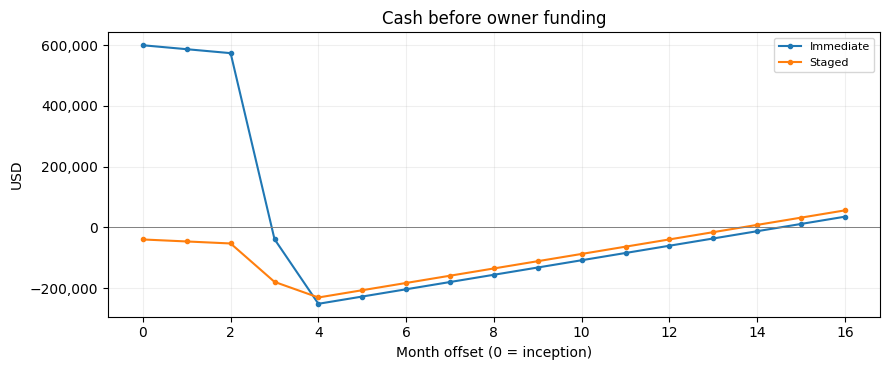

In [5]:
def summary(scenarios):
    show_finance_table(
        [
            "Case",
            "Total interest (USD)",
            "Required initial cash (USD)",
            "Final pre-equity cash (USD)",
        ],
        [
            [
                name,
                sum(r.interest_usd for r in rows),
                maximum_funding_requirement_usd([r.net_cash_usd for r in rows]),
                rows[-1].cumulative_cash_usd,
            ]
            for name, rows in scenarios.items()
        ],
    )


summary({"Immediate": immediate, "Staged": staged})
display(
    plot_finance_series(
        {
            "Immediate": [r.cumulative_cash_usd for r in immediate],
            "Staged": [r.cumulative_cash_usd for r in staged],
        },
        title="Cash before owner funding",
    )
)


def deployment_explorer(values, source=assumptions.copy()):
    from liquid_compute.deployment import build_deployment_funding_schedule

    delay = values["Delay (months)"]
    if delay < 0:
        raise ValueError("delay must be nonnegative")
    current = source | dict(
        milestone_months=(0, 3 + delay, 4 + delay),
        operating_start_month=5 + delay,
        debt_fraction=values["Debt fraction"],
    )
    rows = build_deployment_funding_schedule(**current, draw_strategy="staged")
    return {"Cumulative pre-equity cash": [r.cumulative_cash_usd for r in rows]}


explore_finance_series(
    {"Delay (months)": 0, "Debt fraction": assumptions["debt_fraction"]},
    deployment_explorer,
    title="Deployment timing and owner funding",
);

Staged borrowing needs **USD 231,200** from outside the loan before operations: USD 200,000 toward the purchase, USD 20,000 of site bills, and USD 11,200 of interest. Borrowing everything early needs USD 252,000.

## Experiment 1 — Change only when we borrow

Both choices buy the same equipment, borrow USD 800,000 in total and use the same dates. Once the equipment is accepted, both have the same repayment schedule.

This lets us see the cost of borrowing early on its own.

In [6]:
show_finance_table(
    ["Through acceptance", "Immediate (USD)", "Staged (USD)"],
    [
        [
            "Equipment paid",
            sum(r.capex_usd for r in immediate[:5]),
            sum(r.capex_usd for r in staged[:5]),
        ],
        [
            "Debt drawn",
            sum(r.draw_usd for r in immediate[:5]),
            sum(r.draw_usd for r in staged[:5]),
        ],
        [
            "Interest paid",
            sum(r.interest_usd for r in immediate[:5]),
            sum(r.interest_usd for r in staged[:5]),
        ],
    ],
)

| Through acceptance | Immediate (USD) | Staged (USD) |
| --- | --- | --- |
| Equipment paid | 1,000,000.00 | 1,000,000.00 |
| Debt drawn | 800,000.00 | 800,000.00 |
| Interest paid | 32,000.00 | 11,200.00 |

The **USD 20,800** difference comes only from setup interest. Staging does not make the equipment cheaper. It also depends on the lender making later draws available as promised.

## Experiment 2 — The equipment is two months late

Move delivery to month 5, acceptance to month 6 and the first operating cash to month 7.

Keep all 12 operating months, now ending in month 18. The schedule extends to include every delayed customer receipt. The site has two extra months of bills.

In [7]:
delayed = build_deployment_funding_schedule(
    **(assumptions | dict(milestone_months=(0, 5, 6), operating_start_month=7)),
    draw_strategy="staged",
)
summary({"On time": staged, "Two-month delay": delayed})
print(f"Final boundary: month {delayed[-1].month_offset}")
print(f"Total customer cash retained: USD {sum(r.receipts_usd for r in delayed):,.0f}")

| Case | Total interest (USD) | Required initial cash (USD) | Final pre-equity cash (USD) |
| --- | --- | --- | --- |
| On time | 64,148.37 | 231,200.00 | 55,851.63 |
| Two-month delay | 67,348.37 | 244,400.00 | 42,651.63 |

Final boundary: month 18
Total customer cash retained: USD 1,320,000


Total customer cash is still **USD 1.32 million**. But waiting adds USD 10,000 of site bills and USD 3,200 of interest on the early USD 160,000 loan draw.

The staged plan now needs **USD 244,400** before operations. A delay can require more money even if total sales stay the same.

We have not assumed a customer cancellation, price change or late-delivery penalty. Those would be extra changes to study separately.

## Experiment 3 — Borrow less

Return to the original dates. Borrow 60% of the equipment price instead of 80%. Interest should fall, but the owners must pay more of the purchase themselves.

In [8]:
lower_debt = build_deployment_funding_schedule(
    **(assumptions | dict(debt_fraction=0.60)), draw_strategy="staged"
)
summary({"80% financed": staged, "60% financed": lower_debt})

| Case | Total interest (USD) | Required initial cash (USD) | Final pre-equity cash (USD) |
| --- | --- | --- | --- |
| 80% financed | 64,148.37 | 231,200.00 | 55,851.63 |
| 60% financed | 48,111.28 | 428,400.00 | 71,888.72 |

Setup interest falls to **USD 8,400**. Yet the needed cash rises to **USD 428,400**: USD 400,000 toward the equipment, USD 20,000 for the site and USD 8,400 of interest.

Borrowing less saves interest but leaves a much bigger purchase bill for the owners.

Once working, the project has USD 95,000 a month before loan payments: USD 110,000 minus USD 15,000. We can use F4's 1.25 cushion to check repayments separately. Enough later cash does not prove a lender will fund the earlier setup bills. Those earlier costs have already been counted; do not count the purchase twice.

In [9]:
supported_debt = level_payment_debt_capacity_usd(
    cfads_usd=(95_000,) * 12, minimum_dscr=1.25, nominal_annual_interest_rate=0.12
)
first_operation = staged[5]
coverage = debt_service_coverage(
    cfads_usd=95_000,
    debt_service_usd=first_operation.interest_usd
    + first_operation.principal_repayment_usd,
)
show_finance_table(
    ["Measure", "Value"],
    [
        ["Operating-supported debt (USD)", supported_debt],
        ["Selected commitment (USD)", 800_000],
        ["Operating DSCR", coverage],
        [
            "Meets assumed 1.25 threshold",
            "Yes" if coverage >= 1.25 else "No: coverage shortfall",
        ],
    ],
)

| Measure | Value |
| --- | --- |
| Operating-supported debt (USD) | 855,385.89 |
| Selected commitment (USD) | 800,000.00 |
| Operating DSCR | 1.34 |
| Meets assumed 1.25 threshold | Yes |

## Next — Lending against receivables

Continue to **F6: Receivables and collateral**.

The [World Bank's project-finance guide](https://ppp.worldbank.org/financing/project-finance-concepts) discusses different project phases. Our dates, costs and lending terms are hypothetical. This lesson does not estimate what selling the hardware would recover, and it does not add the customer-prepayment loan from F2.